In [3]:
import kabs
import porespy as ps
import matplotlib.pyplot as plt
import numpy as np
import taichi as ti
from pint import UnitRegistry

edt = ps.tools.get_edt()
u = UnitRegistry()

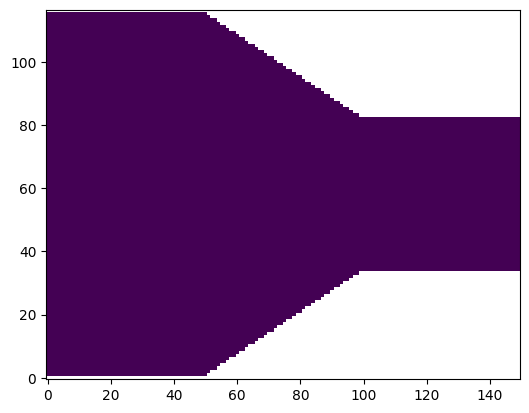

In [4]:
rho = 1000.0 * u.kg/u.m**3  # kg/m³ (water)
mu = 0.001 * u.Pa * u.s
nu = mu / rho
dx = 1e-6 * u.m
Istar = 1/(2*np.pi)
r_p = 58
r_t = 25
L_p = 50
pad = 50
shape = [2*r_p + 1, L_p, 2*r_p + 1]
cone = ps.generators.conical_capillary(np.array(shape), r=[r_p, r_t], axis=1)
cone = np.pad(cone, [[0, 0], [pad, pad], [0, 0]], mode='edge')
ps.imshow(cone, axis=2);

In [5]:
ti.init(arch='metal')
soln_cone = kabs.solve_flow(cone, direction='y')

[Taichi] Starting on arch=arm64


[W 04/14/26 09:48:51.889 10440406] [misc.py:adaptive_arch_select@758] Arch=['metal'] is not supported, falling back to CPU


Step      0/15000  interval 00h00m00s  elapsed 00h00m00s
Step    500/15000  interval 00h00m23s  elapsed 00h00m23s
         |v|=3.7785e+03  delta|v|=3.7785e+03
Step   1000/15000  interval 00h00m23s  elapsed 00h00m47s
         |v|=5.2807e+03  delta|v|=1.5380e+03
Step   1500/15000  interval 00h00m24s  elapsed 00h01m11s
         |v|=5.8933e+03  delta|v|=6.3034e+02
Step   2000/15000  interval 00h00m24s  elapsed 00h01m36s
         |v|=6.1137e+03  delta|v|=2.8841e+02
Step   2500/15000  interval 00h00m25s  elapsed 00h02m02s
         |v|=6.1932e+03  delta|v|=1.5612e+02
Step   3000/15000  interval 00h00m26s  elapsed 00h02m28s
         |v|=6.2140e+03  delta|v|=8.6783e+01
Step   3500/15000  interval 00h00m27s  elapsed 00h02m56s
         |v|=6.2222e+03  delta|v|=4.5031e+01
Step   4000/15000  interval 00h00m29s  elapsed 00h03m26s
         |v|=6.2288e+03  delta|v|=2.1780e+01
Step   4500/15000  interval 00h00m32s  elapsed 00h03m58s
         |v|=6.2359e+03  delta|v|=1.0963e+01
Step   5000/15000  interv

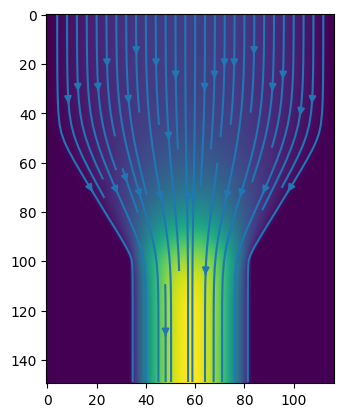

In [7]:
fig, ax = plt.subplots()
ax.imshow(kabs.plot_cross_section(soln_cone, direction='y'))
kabs.add_streamlines(soln_cone, ax=ax, axis=2);

In [ ]:
# Analytical cone conductance in SI, with both closed-form and numerical integral
# evaluations for int(1/A^2 dx).

# Find Q
fluid = soln_cone.solid == 0
u_y = soln_cone.velocity[..., 1]          # axial component (y-direction)
j = fluid.shape[1] // 2                   # pick any interior slice
Q_lu = float(u_y[:, j, :][fluid[:, j, :]].sum())
Q_SI = Q_lu * (nu / soln_cone.nu) * dx

# Build an ideal conical radius profile over the cone section only (no padded tubes).
r_profile = np.linspace(r_p, r_t, L_p) * dx
A_cone_si = np.pi * r_profile**2
A1 = A_cone_si[0]
A2 = A_cone_si[-1]

# Integral S = int(1/A^2 dx), evaluated two ways:
# 1) Numerical quadrature over the discretized ideal cone profile
sf_num = np.sum((1.0 / (A_cone_si**2)) * dx)

# 2) Closed-form conical result
r_p_si = r_p * dx
r_t_si = r_t * dx
L_si = L_p * dx
sf_ana = (r_p_si**2 + r_p_si*r_t_si + r_t_si**2) * L_si / (3 * np.pi**2 * r_p_si**3 * r_t_si**3)

# Viscous resistance: R_visc = 16*pi^2*mu*I* * S
R_visc_cone_num = 16 * np.pi**2 * mu * Istar * sf_num
R_visc_cone_ana = 16 * np.pi**2 * mu * Istar * sf_ana

# Acceleration resistance in textbook form:
# R_acc = rho*Q/2 * (alpha_2/A2^2 - alpha_1/A1^2)
# For fully developed laminar tube flow, alpha_1 = alpha_2 = 2.
alpha_1 = 2.0
alpha_2 = 2.0
R_acc_cone = 0.5 * rho * Q_SI * (alpha_2 / A2**2 - alpha_1 / A1**2)

# Conductance computed from each viscous estimate
Gh_cone_visc_num = R_visc_cone_num**-1
Gh_cone_visc_ana = R_visc_cone_ana**-1
Gh_cone_num = (R_visc_cone_num + R_acc_cone)**-1
Gh_cone_ana = (R_visc_cone_ana + R_acc_cone)**-1

# Keep canonical names for downstream cells (use analytical closed-form by default).
Gh_cone_visc = Gh_cone_visc_ana
Gh_cone = Gh_cone_ana

print('Analytical cone conductance (SI):')
print(f'  alpha_1, alpha_2:                 {alpha_1:.3g}, {alpha_2:.3g}')
print(f'  R_acc_cone:                       {R_acc_cone.to_base_units():~P}')
print('')
print('Integral check for S = int(1/A^2 dx):')
print(f'  S_numerical:                      {sf_num.to_base_units():~P}')
print(f'  S_analytical:                     {sf_ana.to_base_units():~P}')
print(f'  S_num/S_ana:                      {(sf_num / sf_ana).to_base_units().magnitude:.6g}')
print('')
print('Viscous conductance comparison:')
print(f'  Gh_cone_visc_num:                 {Gh_cone_visc_num.to_base_units():~P}')
print(f'  Gh_cone_visc_ana:                 {Gh_cone_visc_ana.to_base_units():~P}')
print(f'  ratio (num/ana):                  {(Gh_cone_visc_num / Gh_cone_visc_ana).to_base_units().magnitude:.6g}')
print('')
print('Total conductance (viscous + acceleration):')
print(f'  Gh_cone_num:                      {Gh_cone_num.to_base_units():~P}')
print(f'  Gh_cone_ana (canonical Gh_cone):  {Gh_cone_ana.to_base_units():~P}')
print(f'  ratio (num/ana):                  {(Gh_cone_num / Gh_cone_ana).to_base_units().magnitude:.6g}')

Analytical cone conductance (SI):
  alpha_1, alpha_2:                 2, 2
  R_acc_cone:                       54499163968.537125 kg/m⁴/s

Integral check for S = int(1/A^2 dx):
  S_numerical:                      3088963003084.907 1/m³
  S_analytical:                     3012756668064.4287 1/m³
  S_num/S_ana:                      1.02529

Viscous conductance comparison:
  Gh_cone_visc_num:                 1.2880936331460538×10⁻¹¹ m⁴·s/kg
  Gh_cone_visc_ana:                 1.3206753865899317×10⁻¹¹ m⁴·s/kg
  ratio (num/ana):                  0.975329

Total conductance (viscous + acceleration):
  Gh_cone_num:                      7.568116542123718×10⁻¹² m⁴·s/kg
  Gh_cone_ana (canonical Gh_cone):  7.679430015231277×10⁻¹² m⁴·s/kg
  ratio (num/ana):                  0.985505


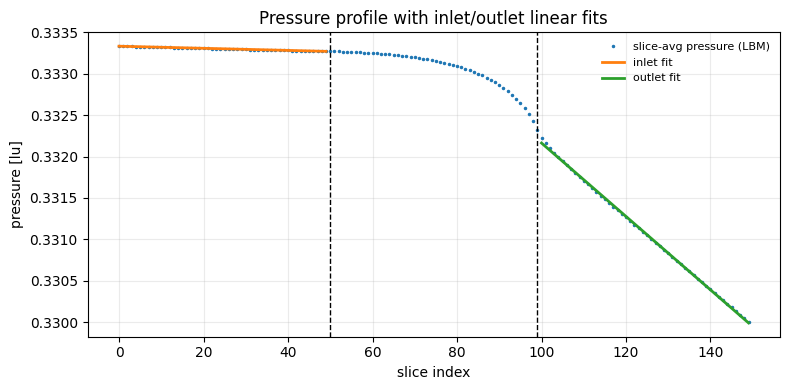

In [16]:
# Cone-only conductance from composite (tube -> cone -> tube) LBM result
# using pressure fits in inlet/outlet tube regions.



def plot_pressure_profile(soln, pad_width):

    n_lead = pad_width  # voxels of cylindrical lead section at each end (edit if needed)
    fluid = soln.solid == 0
    u_y = soln.velocity[..., 1]
    p_lu = soln.rho / 3.0  # D3Q19: p = c_s^2 * rho, c_s^2 = 1/3

    areas = fluid.sum(axis=(0, 2)).astype(float)
    valid = areas > 0
    valid_idx = np.where(valid)[0]

    # Slice-averaged pressure in pore space and slice flow in LU
    p_slice = np.full(fluid.shape[1], np.nan)
    q_slice = np.full(fluid.shape[1], np.nan)
    for j in valid_idx:
        m = fluid[:, j, :]
        p_slice[j] = np.mean(p_lu[:, j, :][m])
        q_slice[j] = np.sum(u_y[:, j, :][m])

    Q_lu = np.nanmean(q_slice[valid_idx])

    j_start = int(valid_idx[0] + n_lead)
    j_end = int(valid_idx[-1] - n_lead)
    if j_end <= j_start + 4:
        raise RuntimeError('Lead length is too large for current domain. Reduce n_lead.')

    # Regions used for linear pressure fits
    fit_in = np.arange(valid_idx[0], j_start)
    fit_out = np.arange(j_end + 1, valid_idx[-1] + 1)
    if len(fit_in) < 2 or len(fit_out) < 2:
        raise RuntimeError('Not enough slices in inlet/outlet fit regions.')

    coef_in = np.polyfit(fit_in, p_slice[fit_in], deg=1)
    coef_out = np.polyfit(fit_out, p_slice[fit_out], deg=1)

    # Extrapolated pressures at cone boundaries
    p_in_cone = np.polyval(coef_in, j_start)
    p_out_cone = np.polyval(coef_out, j_end)
    dP_cone_lu = p_in_cone - p_out_cone

    g_cone_lu = Q_lu / dP_cone_lu
    g_cone_SI = g_cone_lu * soln.nu * dx.magnitude**3 / mu.magnitude

    # Visual check of pressure profile and fit regions
    j_all = np.arange(fluid.shape[1])
    results = {}
    results['j_start'] = j_start
    results['j_end'] = j_end
    results['dP_cone_lu'] = dP_cone_lu
    results['g_cone_lu'] = g_cone_lu
    results['g_cone_SI'] = g_cone_SI
    results['g_cone_SI'] = g_cone_SI
    results['valid_idx'] = valid_idx
    results['p_slice'] = p_slice
    results['q_slice'] = q_slice
    results['fit_in'] = fit_in
    results['fit_out'] = fit_out
    results['coef_in'] = coef_in
    results['coef_out'] = coef_out
    results['j_all'] = j_all
    return results


r = plot_pressure_profile(soln_cone, 50)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r['valid_idx'], r['p_slice'][r['valid_idx']], '.', ms=3, label='slice-avg pressure (LBM)')
ax.plot(r['fit_in'], np.polyval(r['coef_in'], r['fit_in']), '-', lw=2, label='inlet fit')
ax.plot(r['fit_out'], np.polyval(r['coef_out'], r['fit_out']), '-', lw=2, label='outlet fit')
ax.axvline(r['j_start'], ls='--', c='k', lw=1)
ax.axvline(r['j_end'], ls='--', c='k', lw=1)
ax.set_xlabel('slice index')
ax.set_ylabel('pressure [lu]')
ax.set_title('Pressure profile with inlet/outlet linear fits')
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

$$
R = \Delta P / Q = 16 \pi^2 \mu \int_{x_{1}}^{x_{2}}{\frac{I^*_p}{A^2}dx} + \frac{\rho Q}{2} \bigg(\frac{\alpha_2}{A_2^2} - \frac{\alpha_1}{A_1^2}\bigg)
$$

For fully developed laminar flow at both ends, $\alpha_1 = \alpha_2 = 2$, so the inertial term reduces to

$$
R_{\mathrm{acc}} = \rho Q \bigg(\frac{1}{A_2^2} - \frac{1}{A_1^2}\bigg)
$$

In [17]:
# Extended cone model: robust cone-only extraction from composite LBM domain
# R = dP/Q = 16*pi^2*mu*Integral(I*/A^2 dx) + rho*Q/2*(alpha_2/A2^2 - alpha_1/A1^2)

def infer_cone_region_from_area_profile(areas, valid_idx, atol=0.5):
    """Infer inlet tube, cone, and outlet tube regions from cross-sectional area."""
    a = areas[valid_idx]
    a_in = a[0]
    a_out = a[-1]

    non_in = np.where(~np.isclose(a, a_in, atol=atol))[0]
    non_out = np.where(~np.isclose(a, a_out, atol=atol))[0]
    if len(non_in) > 0 and len(non_out) > 0:
        start_pos = int(non_in[0])
        end_pos = int(non_out[-1])
        fit_in = valid_idx[:start_pos]
        fit_out = valid_idx[end_pos + 1:]
        cone = valid_idx[start_pos:end_pos + 1]
        if len(fit_in) >= 2 and len(fit_out) >= 2 and len(cone) >= 3:
            return fit_in, cone, fit_out

    dA = np.diff(a)
    change_pos = np.where(np.abs(dA) > 0)[0]
    if len(change_pos) < 2:
        raise RuntimeError(
            'Could not infer cone boundaries from area profile. '
            'Check geometry or set regions manually.'
        )

    start_pos = int(change_pos[0] + 1)
    end_pos = int(change_pos[-1])
    fit_in = valid_idx[:start_pos]
    fit_out = valid_idx[end_pos + 1:]
    cone = valid_idx[start_pos:end_pos + 1]
    if len(fit_in) < 2 or len(fit_out) < 2 or len(cone) < 3:
        raise RuntimeError(
            'Inferred fit/cone regions are too small. '
            'Check geometry resolution or fit strategy.'
        )
    return fit_in, cone, fit_out


# Diagnostic only: estimate alpha directly from LBM profiles in tube regions
def alpha_from_slice(jj):
    mm = fluid[:, jj, :]
    uu = u_y[:, jj, :][mm]
    ubar = np.mean(uu)
    return np.sum(uu**3) / (len(uu) * ubar**3)


def select_mid_fit_window(idx, keep_fraction=0.5, min_points=4):
    n = len(idx)
    if n < min_points:
        raise RuntimeError('Tube fit region too short for stable linear fit.')
    keep_n = max(min_points, int(round(n * keep_fraction)))
    keep_n = min(keep_n, n)
    start = (n - keep_n) // 2
    return idx[start:start + keep_n]


def solve_hydraulic_conductance(soln):

    fluid = soln.solid == 0
    u_y = soln.velocity[..., 1]
    rho_lu_field = soln.rho
    areas = fluid.sum(axis=(0, 2)).astype(float)
    valid_idx = np.where(areas > 0)[0]

    # Slice pressure and flow in LU
    p_lu = rho_lu_field / 3.0
    p_slice = np.full(fluid.shape[1], np.nan)
    q_slice = np.full(fluid.shape[1], np.nan)
    for j in valid_idx:
        m = fluid[:, j, :]
        p_slice[j] = np.mean(p_lu[:, j, :][m])
        q_slice[j] = np.sum(u_y[:, j, :][m])

    fit_in_full, cone_idx, fit_out_full = infer_cone_region_from_area_profile(areas, valid_idx)
    j_start_local = int(cone_idx[0])
    j_end_local = int(cone_idx[-1])

    # Method 1: full-tube linear fits
    coef_in_full = np.polyfit(fit_in_full, p_slice[fit_in_full], deg=1)
    coef_out_full = np.polyfit(fit_out_full, p_slice[fit_out_full], deg=1)
    dP_fit_full = np.polyval(coef_in_full, j_start_local) - np.polyval(coef_out_full, j_end_local)

    # Method 2: mid-tube linear fits
    fit_in_mid = select_mid_fit_window(fit_in_full, keep_fraction=0.5, min_points=4)
    fit_out_mid = select_mid_fit_window(fit_out_full, keep_fraction=0.5, min_points=4)
    coef_in_mid = np.polyfit(fit_in_mid, p_slice[fit_in_mid], deg=1)
    coef_out_mid = np.polyfit(fit_out_mid, p_slice[fit_out_mid], deg=1)
    dP_fit_mid = np.polyval(coef_in_mid, j_start_local) - np.polyval(coef_out_mid, j_end_local)

    # Method 3 (default): boundary-window pressure inside cone (most robust to pad length)
    k_edge = max(3, min(8, len(cone_idx) // 8))
    pin_idx = cone_idx[:k_edge]
    pout_idx = cone_idx[-k_edge:]
    p_in_edge = np.nanmean(p_slice[pin_idx])
    p_out_edge = np.nanmean(p_slice[pout_idx])
    dP_edge = p_in_edge - p_out_edge

    # Use cone-only flow rate to avoid any tiny tube averaging bias
    Q_lu_cone = np.nanmean(q_slice[cone_idx])

    # Default extraction uses edge-window method
    dP_cone_lu = dP_edge
    R_lbm_lu = dP_cone_lu / Q_lu_cone
    g_lbm_lu = 1.0 / R_lbm_lu

    # Extended analytical resistance in LU
    A_cone = areas[cone_idx]
    A1 = A_cone[0]
    A2 = A_cone[-1]
    rho_lu = float(np.mean(rho_lu_field[fluid]))
    mu_lu = rho_lu * float(soln_cone.nu)
    dx_lu = 1.0

    R_visc_lu = 16.0 * np.pi**2 * mu_lu * np.sum((Istar / (A_cone**2)) * dx_lu)
    alpha_1 = 2.0
    alpha_2 = 2.0
    R_acc_lu = 0.5 * rho_lu * Q_lu_cone * (alpha_2 / A2**2 - alpha_1 / A1**2)
    R_total_lu = R_visc_lu + R_acc_lu
    g_total_lu = 1.0 / R_total_lu

    j_alpha_in = int(fit_in_mid[len(fit_in_mid)//2])
    j_alpha_out = int(fit_out_mid[len(fit_out_mid)//2])
    alpha_1_lbm = alpha_from_slice(j_alpha_in)
    alpha_2_lbm = alpha_from_slice(j_alpha_out)
    alpha_tol = 0.2
    alpha_status = 'OK' if (abs(alpha_1_lbm - 2.0) <= alpha_tol and abs(alpha_2_lbm - 2.0) <= alpha_tol) else 'WARNING'

    r_total_ratio = R_total_lu / R_lbm_lu
    g_total_ratio = g_total_lu / g_lbm_lu
    g_total_SI = g_total_lu * soln_cone.nu * dx.magnitude**3 / mu.magnitude

    results = {}
    results['j_start_local'] = j_start_local
    results['j_end_local'] = j_end_local
    results['fit_in_full'] = fit_in_full
    results['fit_out_full'] = fit_out_full
    results['fit_in_mid'] = fit_in_mid
    results['fit_out_mid'] = fit_out_mid
    results['k_edge'] = k_edge
    results['dP_fit_full'] = dP_fit_full
    results['dP_fit_mid'] = dP_fit_mid
    results['dP_edge'] = dP_edge
    results['Q_lu_cone'] = Q_lu_cone
    results['j_alpha_in'] = j_alpha_in
    results['j_alpha_out'] = j_alpha_out
    results['alpha_1_lbm'] = alpha_1_lbm
    results['alpha_2_lbm'] = alpha_2_lbm
    results['alpha_status'] = alpha_status
    results['alpha_tol'] = alpha_tol
    results['g_total_lu'] = g_total_lu
    results['R_lbm_lu'] = R_lbm_lu
    results['g_lbm_lu'] = g_lbm_lu
    results['g_total_SI'] = g_total_SI
    results['R_visc_lu'] = R_visc_lu
    results['R_acc_lu'] = R_acc_lu
    results['R_total_lu'] = R_total_lu
    results['g_total_lu'] = g_total_lu
    results['r_total_ratio'] = r_total_ratio
    results['g_total_ratio'] = g_total_ratio
    return results


def display_results(results):
    r = results
    print("Cone-only extraction diagnostics (LU):")
    print(f"  cone start/end slices:             {r['j_start_local']}, {r['j_end_local']}")
    print(f"  tube slices in/out (full):         {len(r['fit_in_full'])}, {len(r['fit_out_full'])}")
    print(f"  tube slices in/out (mid-fit):      {len(r['fit_in_mid'])}, {len(r['fit_out_mid'])}")
    print(f"  cone edge window size:             {r['k_edge']}")
    print(f"  dP_fit_full:                       {r['dP_fit_full']:.6g}")
    print(f"  dP_fit_mid:                        {r['dP_fit_mid']:.6g}")
    print(f"  dP_edge (default):                 {r['dP_edge']:.6g}")
    print(f"  Q_lu_cone (default):               {r['Q_lu_cone']:.6g}")
    print("")
    print("Alpha diagnostic from LBM (diagnostic only):")
    print(f"  alpha_1_lbm (inlet, j={r['j_alpha_in']}):   {r['alpha_1_lbm']:.6g}")
    print(f"  alpha_2_lbm (outlet, j={r['j_alpha_out']}):  {r['alpha_2_lbm']:.6g}")
    print(f"  target alpha for developed laminar:     2.0 +/- {r['alpha_tol']:.1f}")
    print(f"  development status:                      {r['alpha_status']}")
    print("")
    print("Cone resistance/conductance used for comparison:")
    print(f"  R_lbm_lu = dP/Q:                   {r['R_lbm_lu']:.6g}")
    print(f"  g_lbm_lu = 1/R_lbm:                {r['g_lbm_lu']:.6g}")
    print("")
    print("Model prediction in LU (alpha_1=alpha_2=2):")
    print(f"  R_visc_lu:                         {r['R_visc_lu']:.6g}")
    print(f"  R_acc_lu:                          {r['R_acc_lu']:.6g}")
    print(f"  R_total_lu:                        {r['R_total_lu']:.6g}")
    print(f"  g_total_lu = 1/R_total:            {r['g_total_lu']:.6g}")
    print("")
    print("Relative comparison to LBM (using default edge-window extraction):")
    print(f"  R_total/R_lbm:                     {r['r_total_ratio']:.6g} ({(r['r_total_ratio'] - 1.0)*100:+.2f}% vs LBM)")
    print(f"  g_total/g_lbm:                     {r['g_total_ratio']:.6g} ({(r['g_total_ratio'] - 1.0)*100:+.2f}% vs LBM)")
    print(f"  g_total_SI:                        {r['g_total_SI']:.6e} m^3/(Pa.s)")


def plot_pressure_profile(soln, pad_width):

    n_lead = pad_width  # voxels of cylindrical lead section at each end (edit if needed)
    fluid = soln.solid == 0
    u_y = soln.velocity[..., 1]
    p_lu = soln.rho / 3.0  # D3Q19: p = c_s^2 * rho, c_s^2 = 1/3

    areas = fluid.sum(axis=(0, 2)).astype(float)
    valid = areas > 0
    valid_idx = np.where(valid)[0]

    # Slice-averaged pressure in pore space and slice flow in LU
    p_slice = np.full(fluid.shape[1], np.nan)
    q_slice = np.full(fluid.shape[1], np.nan)
    for j in valid_idx:
        m = fluid[:, j, :]
        p_slice[j] = np.mean(p_lu[:, j, :][m])
        q_slice[j] = np.sum(u_y[:, j, :][m])

    Q_lu = np.nanmean(q_slice[valid_idx])

    j_start = int(valid_idx[0] + n_lead)
    j_end = int(valid_idx[-1] - n_lead)
    if j_end <= j_start + 4:
        raise RuntimeError('Lead length is too large for current domain. Reduce n_lead.')

    # Regions used for linear pressure fits
    fit_in = np.arange(valid_idx[0], j_start)
    fit_out = np.arange(j_end + 1, valid_idx[-1] + 1)
    if len(fit_in) < 2 or len(fit_out) < 2:
        raise RuntimeError('Not enough slices in inlet/outlet fit regions.')

    coef_in = np.polyfit(fit_in, p_slice[fit_in], deg=1)
    coef_out = np.polyfit(fit_out, p_slice[fit_out], deg=1)

    # Extrapolated pressures at cone boundaries
    p_in_cone = np.polyval(coef_in, j_start)
    p_out_cone = np.polyval(coef_out, j_end)
    dP_cone_lu = p_in_cone - p_out_cone

    g_cone_lu = Q_lu / dP_cone_lu
    g_cone_SI = g_cone_lu * soln.nu * dx.magnitude**3 / mu.magnitude

    # Visual check of pressure profile and fit regions
    j_all = np.arange(fluid.shape[1])
    results = {}
    results['j_start'] = j_start
    results['j_end'] = j_end
    results['dP_cone_lu'] = dP_cone_lu
    results['g_cone_lu'] = g_cone_lu
    results['g_cone_SI'] = g_cone_SI
    results['g_cone_SI'] = g_cone_SI
    results['valid_idx'] = valid_idx
    results['p_slice'] = p_slice
    results['q_slice'] = q_slice
    results['fit_in'] = fit_in
    results['fit_out'] = fit_out
    results['coef_in'] = coef_in
    results['coef_out'] = coef_out
    results['j_all'] = j_all
    return results


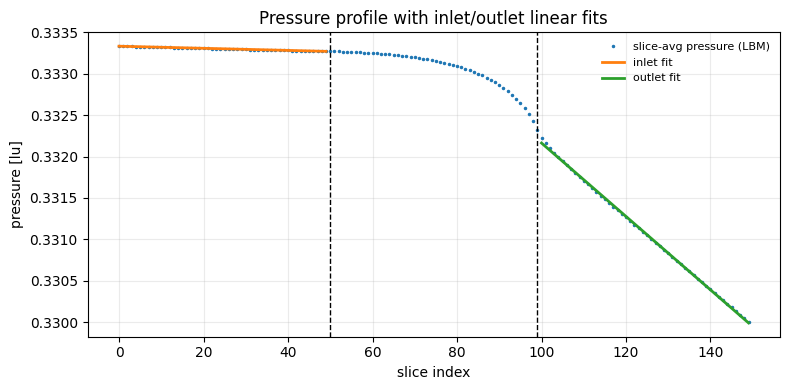

In [18]:
r = plot_pressure_profile(soln_cone, 50)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r['valid_idx'], r['p_slice'][r['valid_idx']], '.', ms=3, label='slice-avg pressure (LBM)')
ax.plot(r['fit_in'], np.polyval(r['coef_in'], r['fit_in']), '-', lw=2, label='inlet fit')
ax.plot(r['fit_out'], np.polyval(r['coef_out'], r['fit_out']), '-', lw=2, label='outlet fit')
ax.axvline(r['j_start'], ls='--', c='k', lw=1)
ax.axvline(r['j_end'], ls='--', c='k', lw=1)
ax.set_xlabel('slice index')
ax.set_ylabel('pressure [lu]')
ax.set_title('Pressure profile with inlet/outlet linear fits')
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

In [8]:
results = solve_hydraulic_conductance(soln_cone)
display_results(results)

Cone-only extraction diagnostics (LU):
  cone start/end slices:             51, 98
  tube slices in/out (full):         51, 51
  tube slices in/out (mid-fit):      26, 26
  cone edge window size:             6
  dP_fit_full:                       0.00100843
  dP_fit_mid:                        0.00104055
  dP_edge (default):                 0.000664388
  Q_lu_cone (default):               36.2769

Alpha diagnostic from LBM (diagnostic only):
  alpha_1_lbm (inlet, j=25):   2.14289
  alpha_2_lbm (outlet, j=124):  2.01075
  target alpha for developed laminar:     2.0 +/- 0.2
  development status:                      OK

Cone resistance/conductance used for comparison:
  R_lbm_lu = dP/Q:                   1.83144e-05
  g_lbm_lu = 1/R_lbm:                54601.9

Model prediction in LU (alpha_1=alpha_2=2):
  R_visc_lu:                         1.26398e-05
  R_acc_lu:                          8.76462e-06
  R_total_lu:                        2.14044e-05
  g_total_lu = 1/R_total:            46